<a href="https://colab.research.google.com/github/Deepak052004/TeamVibeCoder/blob/main/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
df_fake = pd.read_csv('Fake.csv', engine='python', on_bad_lines='skip')
df_true = pd.read_csv('True.csv', engine='python', on_bad_lines='skip')

In [3]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
df_true['labels'] = 1
df_fake['labels'] = 0

df = pd.concat([df_fake, df_true], ignore_index=True)
df.drop(columns = ['title', 'subject', 'date'], inplace=True)
print(df.head())
print(df.shape)

                                                text  labels
0  Donald Trump just couldn t wish all Americans ...       0
1  House Intelligence Committee Chairman Devin Nu...       0
2  On Friday, it was revealed that former Milwauk...       0
3  On Christmas day, Donald Trump announced that ...       0
4  Pope Francis used his annual Christmas Day mes...       0
(1231, 2)


In [6]:
df.duplicated().sum()

np.int64(4)

In [7]:
df.isna().sum()

,0
text,0
labels,0


In [8]:
df = df.drop_duplicates()
df.shape

(1227, 2)

In [9]:
y = df['labels']

In [10]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['text'])

In [11]:
tokenizer.word_index

{'the': 1,
 'to': 2,
 'a': 3,
 'of': 4,
 'and': 5,
 'in': 6,
 'that': 7,
 'on': 8,
 'for': 9,
 'trump': 10,
 's': 11,
 'is': 12,
 'said': 13,
 'he': 14,
 'with': 15,
 'it': 16,
 'was': 17,
 'his': 18,
 'as': 19,
 'by': 20,
 '”': 21,
 'has': 22,
 'not': 23,
 'u': 24,
 'be': 25,
 'from': 26,
 'have': 27,
 'would': 28,
 'tax': 29,
 'at': 30,
 'who': 31,
 'this': 32,
 'are': 33,
 'house': 34,
 'president': 35,
 'an': 36,
 'they': 37,
 'but': 38,
 'republican': 39,
 'about': 40,
 'will': 41,
 'senate': 42,
 'had': 43,
 'donald': 44,
 'their': 45,
 'you': 46,
 'i': 47,
 'reuters': 48,
 'or': 49,
 'we': 50,
 'bill': 51,
 'been': 52,
 'which': 53,
 'more': 54,
 'after': 55,
 'were': 56,
 'white': 57,
 't': 58,
 'one': 59,
 'people': 60,
 'if': 61,
 'also': 62,
 'washington': 63,
 'when': 64,
 'republicans': 65,
 'over': 66,
 'out': 67,
 'all': 68,
 'year': 69,
 'up': 70,
 'him': 71,
 'she': 72,
 'new': 73,
 'state': 74,
 'percent': 75,
 'no': 76,
 'could': 77,
 'so': 78,
 'what': 79,
 'than': 

In [12]:
sequences = tokenizer.texts_to_sequences(df['text'])

In [13]:
max_seq_len = max(len(seq) for seq in sequences)
print(max_seq_len)
X = pad_sequences(sequences, maxlen=max_seq_len)

1401


In [14]:
X_train, X_dummy, y_train, y_dummy = train_test_split(X, y, test_size=0.2, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_dummy, y_dummy, test_size=0.5, random_state=42)

In [15]:
word_counts = len(tokenizer.word_index) + 1

In [16]:
model = Sequential([
    Embedding(word_counts, 300, input_length=max_seq_len),
    LSTM(256, return_sequences=True),
    LSTM(128, return_sequences=True),
    LSTM(64, return_sequences=False),

    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=10,
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - accuracy: 0.7643 - loss: 0.4656 - val_accuracy: 0.8293 - val_loss: 0.5868
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.9642 - loss: 0.1346 - val_accuracy: 0.9919 - val_loss: 0.0286
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 0.0080
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9919 - val_loss: 0.0104
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9919 - val_loss: 0.0133
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 1.0000 - loss: 7.6711e-04 - val_accuracy: 0.9919 - val_loss: 0.0162
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 1.0000 - loss: 6.0595e-04 - val_accuracy: 0.9919 - val_loss: 0.0190
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 1.0000 - loss: 4.9552e-04 - v

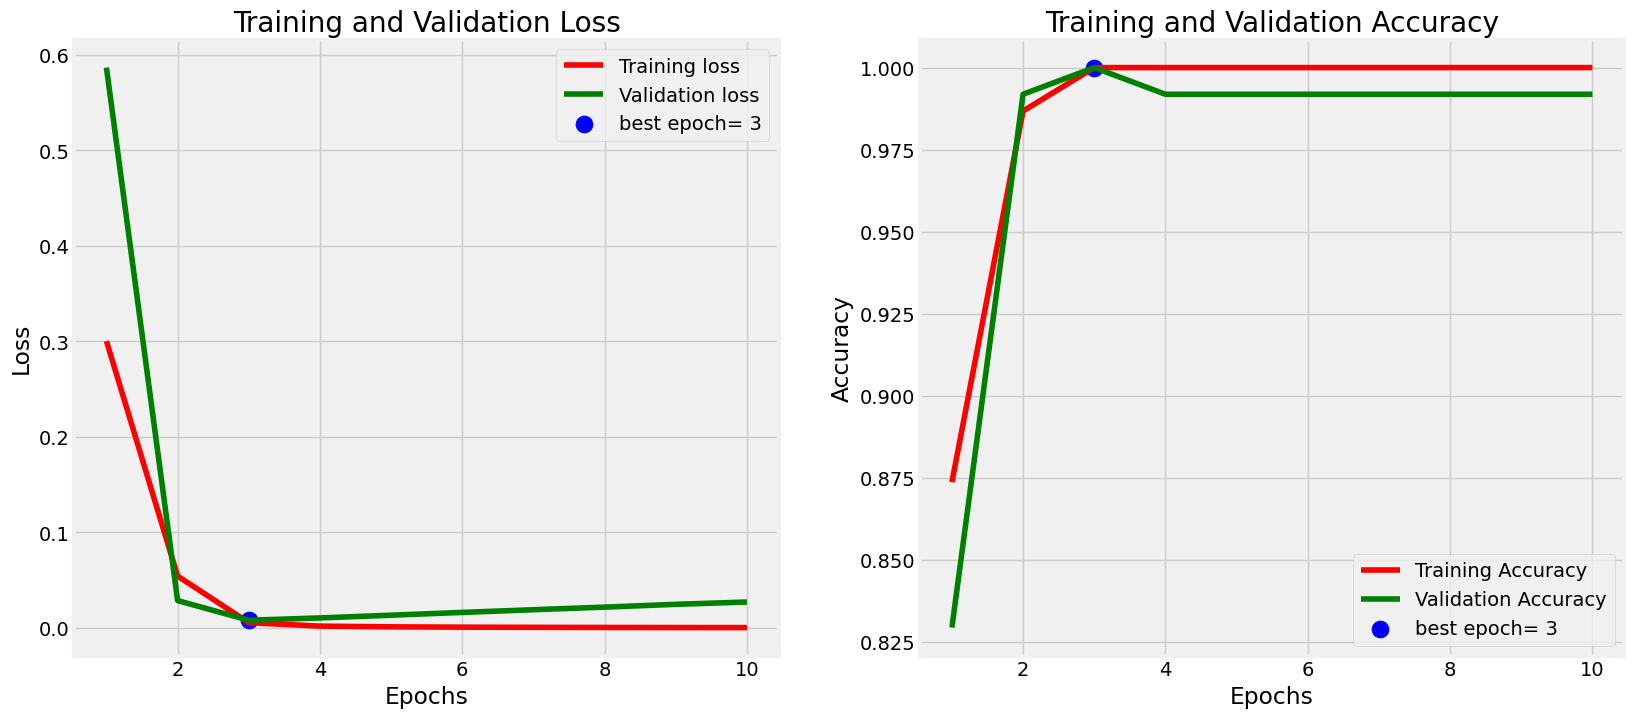

In [18]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()